# ML Home Price — Industry Standard EDA
Inline graphs in Jupyter. Run `jupyter lab` then Shift+Enter each cell.
Same logic as `train.py` but `plt.show()` renders inline via `%matplotlib inline`.

In [2]:
%matplotlib inline
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
df = pd.read_csv(Path("data/home_prices.csv"))
df.head(6)

,area_sqft,bedrooms,bathrooms,age_years,garage_spaces,location_score,distance_to_city_km,price
0,2098,2,2,40,0,6.05,30.76,371014
1,1717,2,2,0,2,5.71,33.91,295878
2,2189,3,1,4,0,2.03,24.74,325912
3,2714,3,3,19,0,8.74,4.00,573406
4,1660,5,3,7,2,7.51,19.76,341342
5,1660,5,1,42,1,1.61,3.57,233554


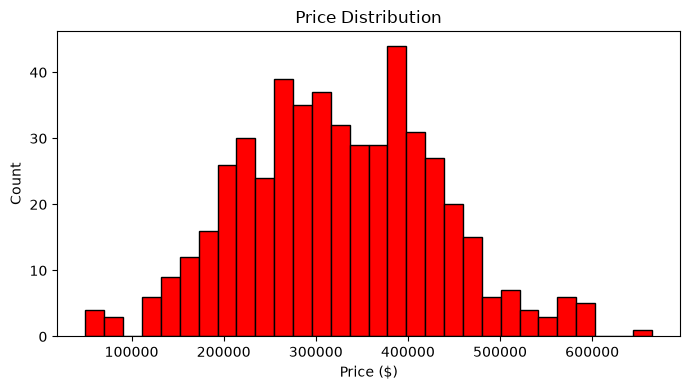

In [3]:
# Price distribution
plt.figure(figsize=(7,4))
plt.hist(df["price"], bins=30, color="red", edgecolor="black")
plt.title("Price Distribution")
plt.xlabel("Price ($)"); plt.ylabel("Count")
plt.tight_layout(); plt.show()

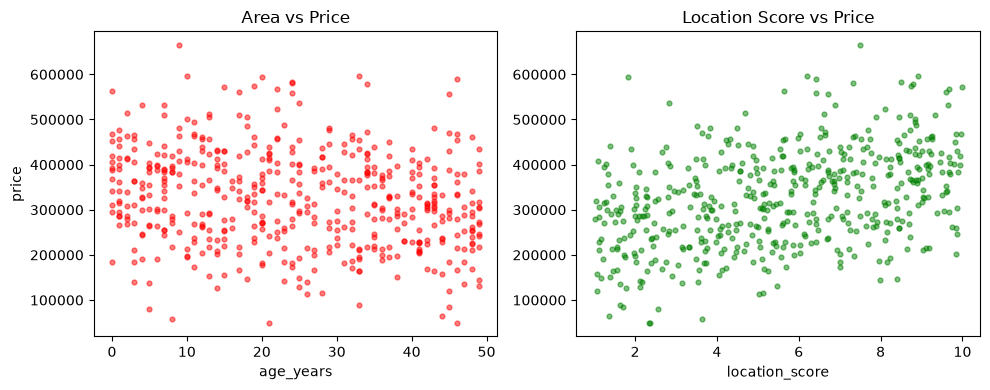

In [4]:
# Area vs Price + Location vs Price
fig, axes = plt.subplots(1,2, figsize=(10,4))
axes[0].scatter(df["age_years"], df["price"], alpha=0.5, s=12, color="red")
axes[0].set(title="Area vs Price", xlabel="age_years", ylabel="price")
axes[1].scatter(df["location_score"], df["price"], alpha=0.5, s=12, color="green")
axes[1].set(title="Location Score vs Price", xlabel="location_score")
plt.tight_layout(); plt.show()

In [6]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# Select columns for PCA
pca_columns = [
    "area_sqft",
    "bedrooms",
    "bathrooms",
    "age_years",
    "garage_spaces",
    "location_score",
    "distance_to_city_km",
    "price"
]

X = df[pca_columns]

# Standardize the data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Apply PCA
pca = PCA()
X_pca = pca.fit_transform(X_scaled)

# Explained variance
explained_variance = pca.explained_variance_ratio_

print("Explained variance ratio:")
for i, variance in enumerate(explained_variance, 1):
    print(f"PC{i}: {variance:.4f} ({variance*100:.2f}%)")

Explained variance ratio:
PC1: 0.2667 (26.67%)
PC2: 0.1366 (13.66%)
PC3: 0.1331 (13.31%)
PC4: 0.1273 (12.73%)
PC5: 0.1206 (12.06%)
PC6: 0.1106 (11.06%)
PC7: 0.1017 (10.17%)
PC8: 0.0034 (0.34%)


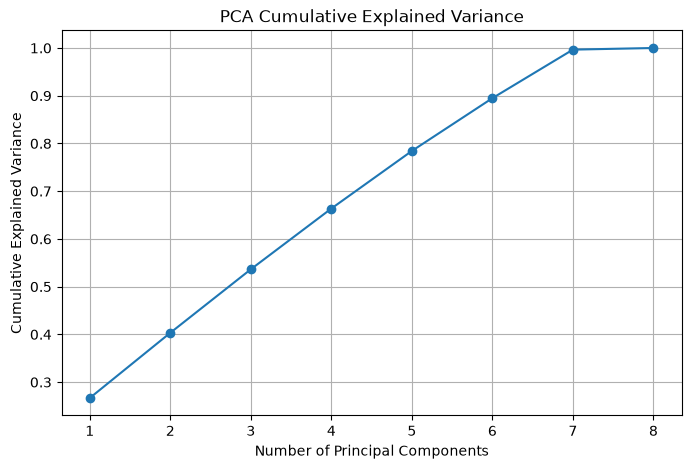

In [7]:
import numpy as np

cumulative_variance = np.cumsum(explained_variance)

plt.figure(figsize=(8, 5))

plt.plot(
    range(1, len(cumulative_variance) + 1),
    cumulative_variance,
    marker="o"
)

plt.xlabel("Number of Principal Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("PCA Cumulative Explained Variance")

plt.xticks(range(1, len(pca_columns) + 1))
plt.grid()
plt.show()

In [8]:
print("\n" + "=" * 50)
print("MISSING VALUES PER COLUMN")
print("=" * 50)
missing_counts = df.isnull().sum()
print(missing_counts)
 
total_missing = missing_counts.sum()
print(f"\nTotal missing values in the whole dataset: {total_missing}")


MISSING VALUES PER COLUMN
area_sqft              0
bedrooms               0
bathrooms              0
age_years              0
garage_spaces          0
location_score         0
distance_to_city_km    0
price                  0
dtype: int64

Total missing values in the whole dataset: 0


In [19]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

X = df.drop(columns=["price"])
y = df["price"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

models = {
    "Linear Regression": LinearRegression(),
    "Decision Tree": DecisionTreeRegressor(max_depth=5, random_state=42),
    "Random Forest": RandomForestRegressor(n_estimators=200, random_state=42),
}
results=[]; preds_dict={}
for name, m in models.items():
    m.fit(X_train, y_train)
    preds = m.predict(X_test)
    preds_dict[name]=preds
    results.append({"Model":name, "MAE":mean_absolute_error(y_test,preds), "RMSE":np.sqrt(mean_squared_error(y_test,preds)), "R2":r2_score(y_test,preds)})
import pandas as pd
results_df = pd.DataFrame(results).sort_values("R2", ascending=False)
results_df

,Model,MAE,RMSE,R2
0,Linear Regression,20267.589282,25254.403161,0.939562
2,Random Forest,28045.087250,33845.868091,0.891445
1,Decision Tree,37709.198863,47759.049262,0.783853


In [24]:
# ============================================================
# HOUSE PRICE PREDICTION - COMPLETE ML PROJECT
# PCA + Linear Regression + Random Forest + Decision Tree
# + Neural Network + Graphs
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.neural_network import MLPRegressor

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


# ============================================================
# 1. LOAD DATASET
# ============================================================

df = pd.read_csv("home_prices.csv")

print("Dataset shape:", df.shape)
print("\nFirst 5 rows:")
display(df.head())


# ============================================================
# 2. SELECT FEATURES AND TARGET
# ============================================================

features = [
    "area_sqft",
    "bedrooms",
    "bathrooms",
    "age_years",
    "garage_spaces",
    "location_score",
    "distance_to_city_km"
]

X = df[features]
y = df["price"]

print("\nFeatures:")
print(features)

print("\nTarget: price")


# ============================================================
# 3. TRAIN / TEST SPLIT
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("\nTraining samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])


# ============================================================
# 4. SCALE FEATURES
# ============================================================

X_scaler = StandardScaler()

X_train_scaled = X_scaler.fit_transform(X_train)
X_test_scaled = X_scaler.transform(X_test)


# ============================================================
# 5. PCA
# Keep 95% of the variance
# ============================================================

pca = PCA(n_components=0.95)

X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

print("\nOriginal number of features:", X_train.shape[1])
print("Number of PCA components:", X_train_pca.shape[1])

print("\nExplained variance ratio:")
print(pca.explained_variance_ratio_)

print(
    "\nTotal explained variance:",
    pca.explained_variance_ratio_.sum()
)


# ============================================================
# 6. SCALE TARGET FOR NEURAL NETWORK
# ============================================================

y_scaler = StandardScaler()

y_train_scaled = y_scaler.fit_transform(
    y_train.to_numpy().reshape(-1, 1)
).ravel()


# ============================================================
# 7. CREATE MODELS
# ============================================================

models = {

    "Linear Regression": LinearRegression(),

    "Random Forest": RandomForestRegressor(
        n_estimators=200,
        random_state=42
    ),

    "Decision Tree": DecisionTreeRegressor(
        random_state=42
    ),

    "Neural Network (10 Iterations)": MLPRegressor(
        hidden_layer_sizes=(64, 32),
        activation="relu",
        solver="adam",
        max_iter=10,
        random_state=42
    )
}


# ============================================================
# 8. TRAIN MODELS AND EVALUATE
# ============================================================

results = []

predictions = {}

for name, model in models.items():

    print("\nTraining:", name)

    # Neural Network uses scaled target
    if "Neural Network" in name:

        model.fit(
            X_train_pca,
            y_train_scaled
        )

        # Prediction in scaled form
        pred_scaled = model.predict(X_test_pca)

        # Convert prediction back to original price
        pred = y_scaler.inverse_transform(
            pred_scaled.reshape(-1, 1)
        ).ravel()

    else:

        model.fit(
            X_train_pca,
            y_train
        )

        pred = model.predict(X_test_pca)


    # Save predictions
    predictions[name] = pred


    # Calculate metrics
    mae = mean_absolute_error(
        y_test,
        pred
    )

    rmse = np.sqrt(
        mean_squared_error(
            y_test,
            pred
        )
    )

    r2 = r2_score(
        y_test,
        pred
    )


    results.append({
        "Model": name,
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2
    })


# ============================================================
# 9. RESULTS TABLE
# ============================================================

results_df = pd.DataFrame(results)

print("\n================ MODEL RESULTS ================\n")

display(
    results_df.sort_values(
        by="R2",
        ascending=False
    ).reset_index(drop=True)
)


# ============================================================
# 10. FIND BEST MODEL
# ============================================================

best_model = results_df.loc[
    results_df["R2"].idxmax()
]

print("\n================ BEST MODEL ================\n")

print("Best Model:", best_model["Model"])
print("MAE:", round(best_model["MAE"], 2))
print("RMSE:", round(best_model["RMSE"], 2))
print("R2:", round(best_model["R2"], 4))


# ============================================================
# 11. GRAPH 1 - MODEL R2 COMPARISON
# ============================================================

plt.figure(figsize=(10, 5))

plt.bar(
    results_df["Model"],
    results_df["R2"]
)

plt.xlabel("Model")
plt.ylabel("R² Score")
plt.title("Model Performance Comparison - R²")

plt.xticks(
    rotation=20,
    ha="right"
)

plt.axhline(
    y=0,
    linestyle="--"
)

plt.tight_layout()
plt.show()


# ============================================================
# 12. GRAPH 2 - MAE COMPARISON
# ============================================================

plt.figure(figsize=(10, 5))

plt.bar(
    results_df["Model"],
    results_df["MAE"]
)

plt.xlabel("Model")
plt.ylabel("MAE")
plt.title("Model Comparison - Mean Absolute Error")

plt.xticks(
    rotation=20,
    ha="right"
)

plt.tight_layout()
plt.show()


# ============================================================
# 13. GRAPH 3 - RMSE COMPARISON
# ============================================================

plt.figure(figsize=(10, 5))

plt.bar(
    results_df["Model"],
    results_df["RMSE"]
)

plt.xlabel("Model")
plt.ylabel("RMSE")
plt.title("Model Comparison - Root Mean Squared Error")

plt.xticks(
    rotation=20,
    ha="right"
)

plt.tight_layout()
plt.show()


# ============================================================
# 14. GRAPH 4 - NEURAL NETWORK LOSS
# ============================================================

nn_model = models["Neural Network (10 Iterations)"]

plt.figure(figsize=(8, 5))

plt.plot(
    range(1, len(nn_model.loss_curve_) + 1),
    nn_model.loss_curve_,
    marker="o"
)

plt.xlabel("Iteration")
plt.ylabel("Loss")
plt.title("Neural Network Training Loss")

plt.xticks(
    range(
        1,
        len(nn_model.loss_curve_) + 1
    )
)

plt.grid(True)

plt.tight_layout()
plt.show()


# ============================================================
# 15. GRAPH 5 - ACTUAL VS PREDICTED PRICE
# Best model
# ============================================================

best_model_name = best_model["Model"]

best_predictions = predictions[best_model_name]

plt.figure(figsize=(8, 6))

plt.scatter(
    y_test,
    best_predictions,
    alpha=0.6
)

# Perfect prediction line
min_value = min(
    y_test.min(),
    best_predictions.min()
)

max_value = max(
    y_test.max(),
    best_predictions.max()
)

plt.plot(
    [min_value, max_value],
    [min_value, max_value],
    linestyle="--"
)

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")

plt.title(
    f"Actual vs Predicted Price - {best_model_name}"
)

plt.tight_layout()
plt.show()


# ============================================================
# 16. PCA EXPLAINED VARIANCE GRAPH
# ============================================================

plt.figure(figsize=(8, 5))

plt.plot(
    range(
        1,
        len(pca.explained_variance_ratio_) + 1
    ),
    np.cumsum(
        pca.explained_variance_ratio_
    ),
    marker="o"
)

plt.xlabel("Number of Principal Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("PCA Explained Variance")

plt.axhline(
    y=0.95,
    linestyle="--"
)

plt.grid(True)

plt.tight_layout()
plt.show()


print("\n================ PROJECT COMPLETE ================")

FileNotFoundError: [Errno 2] No such file or directory: 'home_prices.csv'

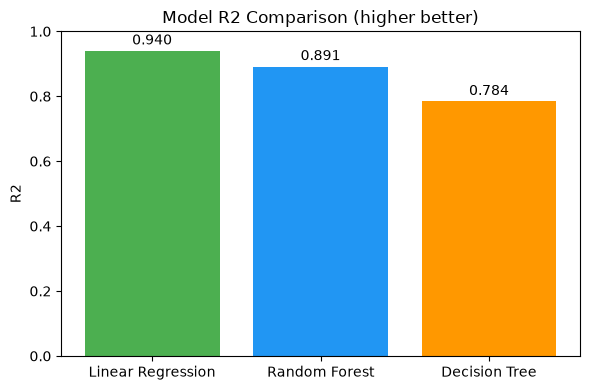

In [4]:
# Bar graph: R2 comparison — industry standard view
plt.figure(figsize=(6,4))
plt.bar(results_df["Model"], results_df["R2"], color=["#4CAF50","#2196F3","#FF9800"])
plt.title("Model R2 Comparison (higher better)")
plt.ylabel("R2"); plt.ylim(0,1)
for i,v in enumerate(results_df["R2"]): plt.text(i, v+0.02, f"{v:.3f}", ha="center")
plt.tight_layout(); plt.show()

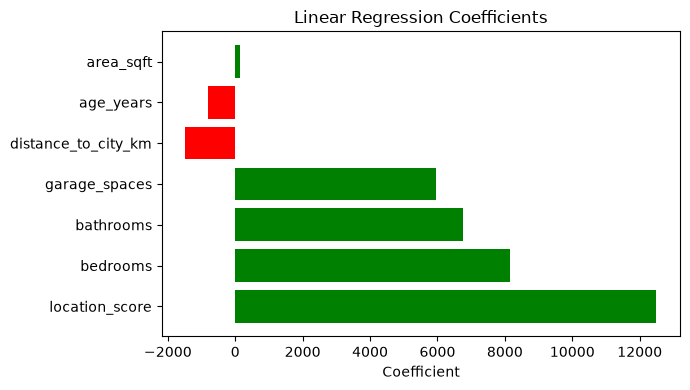

,Feature,Coefficient
5,location_score,12495.975697
1,bedrooms,8149.479024
2,bathrooms,6753.842277
4,garage_spaces,5949.109586
6,distance_to_city_km,-1482.160892
3,age_years,-793.988197
0,area_sqft,153.663971


In [5]:
# LR coefficients bar
lr = models["Linear Regression"]
coef_df = pd.DataFrame({"Feature":X.columns, "Coefficient":lr.coef_}).sort_values("Coefficient", key=abs, ascending=False)
plt.figure(figsize=(7,4))
colors=["green" if c>0 else "red" for c in coef_df["Coefficient"]]
plt.barh(coef_df["Feature"], coef_df["Coefficient"], color=colors)
plt.title("Linear Regression Coefficients"); plt.xlabel("Coefficient")
plt.tight_layout(); plt.show()
coef_df

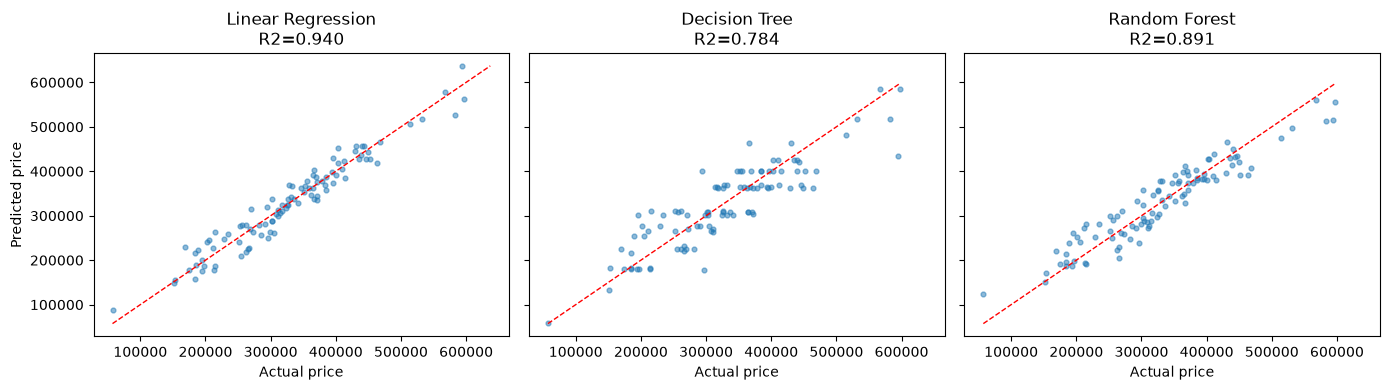

In [6]:
# Actual vs Predicted
fig, axes = plt.subplots(1,3, figsize=(14,4), sharex=True, sharey=True)
for ax, (name, preds) in zip(axes, preds_dict.items()):
    ax.scatter(y_test, preds, alpha=0.5, s=12)
    lo, hi = min(y_test.min(), preds.min()), max(y_test.max(), preds.max())
    ax.plot([lo,hi],[lo,hi],"r--", lw=1)
    ax.set(title=f"{name}\nR2={r2_score(y_test,preds):.3f}", xlabel="Actual price")
axes[0].set_ylabel("Predicted price")
plt.tight_layout(); plt.show()